# 02 Deep learning — autoencoder (self-sufficient)

**Only** this notebook + **`cic_ids_data`** (Colab `MyDrive/cic_ids_data` or local `./cic_ids_data`). The autoencoder is a **local `nn.Module` class in a later cell** — not `src.flow_autoencoder`. No `src/ids_pipeline` or other `src` imports; everything needed is inlined here.

**Data budget:** next cell targets **~50k+ benign training rows** (75/25 train/val split). **Web UI** expects `artifacts/dl/ae_weights.pt` and `artifacts/dl/dl_manifest.pkl` at project root after training.

**Scapy / live demo:** see notebook 03 intro (`sudo`, interface name, PCAP fallback).


In [1]:
# --- Inline CIC helpers: standalone — do not import src.ids_pipeline, src.flow_autoencoder, or src.__init__ ---
from __future__ import annotations

import json
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Sequence, Tuple

import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

try:
    from tqdm.auto import tqdm
except ImportError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "tqdm"])
    from tqdm.auto import tqdm


CIC_DAY_FILES = [
    "Monday-WorkingHours.pcap_ISCX.csv",
    "Tuesday-WorkingHours.pcap_ISCX.csv",
    "Wednesday-workingHours.pcap_ISCX.csv",
    "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
    "Friday-WorkingHours-Morning.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
]


@dataclass
class PreprocessArtifacts:
    features: List[str]
    dropped_corr_cols: List[str]
    benign_train_indices: List[int]
    benign_val_indices: List[int]
    feature_impute_medians: List[float]


def _impute_features_to_float32(
    df: pd.DataFrame, features: List[str], medians: np.ndarray
) -> np.ndarray:
    x = (
        df.reindex(columns=features)
        .replace([np.inf, -np.inf], np.nan)
        .to_numpy(dtype=np.float64)
    )
    med = np.asarray(medians, dtype=np.float64)
    med = np.where(np.isfinite(med), med, 0.0)
    nan_m = np.isnan(x)
    if nan_m.any():
        x = x.copy()
        x[nan_m] = np.broadcast_to(med, x.shape)[nan_m]
    np.nan_to_num(x, copy=False, nan=0.0, posinf=0.0, neginf=0.0)
    return x.astype(np.float32, copy=False)


def norm_family(label: str) -> str:
    s = str(label).strip().replace("\x00", "")
    low = s.lower()
    if low == "benign":
        return "Benign"
    if "heartbleed" in low:
        return "Heartbleed"
    if "web attack" in low or "webattack" in low:
        return "WebAttack"
    if "portscan" in low:
        return "PortScan"
    if "dos" in low and "ddos" not in low:
        return "DoS"
    if "ddos" in low:
        return "DDoS"
    if "bot" in low:
        return "Bot"
    if "infiltration" in low:
        return "Infiltration"
    return s


def cic_report_row_name(raw_label: str) -> str:
    s = str(raw_label).strip()
    low = s.lower().replace("_", " ")
    if low == "benign":
        return "Benign (Validation)"
    if "ftp" in low and "patator" in low:
        return "FTP Bruteforce"
    if "ssh" in low and "patator" in low:
        return "SSH Bruteforce"
    if "slowloris" in low:
        return "DoS (Slowloris)"
    if "goldeneye" in low:
        return "DoS (GoldenEye)"
    if "hulk" in low:
        return "DoS (Hulk)"
    if "slowhttptest" in low or "slowhttps" in low:
        return "DoS (Slowhttps)"
    if "ddos" in low:
        return "DDoS"
    if "dos" in low and "ddos" not in low:
        return "DoS (other)"
    if "heartbleed" in low:
        return "Heartbleed"
    if "web" in low and ("bf" in low or "brute" in low):
        return "Web BF"
    if "xss" in low:
        return "Web XSS"
    if "sql" in low:
        return "Web SQL"
    if "infiltration" in low:
        return "Infiltration"
    if "bot" in low:
        return "Botnet"
    if "portscan" in low:
        return "PortScan"
    return s


def load_cic_data(
    data_dir: str | Path,
    chunk_rows: int = 200_000,
    max_total_rows: int | None = 900_000,
    max_benign_fraction: float = 0.7,
    seed: int = 42,
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    data_dir = Path(data_dir)
    target_total = int(max_total_rows) if max_total_rows else None
    target_benign = None if target_total is None else int(target_total * max_benign_fraction)
    per_file_benign = (
        None if target_benign is None else int(np.ceil(target_benign / len(CIC_DAY_FILES)))
    )
    per_file_attack = (
        None
        if target_total is None
        else int(np.ceil((target_total - target_benign) / len(CIC_DAY_FILES)))
    )

    benign_parts: List[pd.DataFrame] = []
    attack_parts: List[pd.DataFrame] = []
    for file_name in tqdm(CIC_DAY_FILES, desc="CIC CSV files"):
        csv_path = data_dir / file_name
        kept_benign = 0
        kept_attack = 0
        for chunk in pd.read_csv(csv_path, low_memory=True, chunksize=chunk_rows):
            chunk.columns = [c.strip() for c in chunk.columns]
            raw = chunk["Label"].astype(str).str.strip()
            y = (raw.str.lower() != "benign").astype(np.int8)
            fam = raw.map(norm_family)
            x = chunk.drop(columns=["Label"], errors="ignore").select_dtypes(include=[np.number])
            if x.empty:
                continue
            x = x.replace([np.inf, -np.inf], np.nan).astype(np.float32, copy=False)
            x["y"] = y.values
            x["attack_family"] = fam.values
            x["cic_label"] = raw.values
            benign = x[x["y"] == 0]
            attack = x[x["y"] == 1]

            if per_file_benign is not None and len(benign):
                remaining = max(0, per_file_benign - kept_benign)
                if len(benign) > remaining:
                    benign = benign.iloc[rng.choice(len(benign), size=remaining, replace=False)]
            if per_file_attack is not None and len(attack):
                remaining = max(0, per_file_attack - kept_attack)
                if len(attack) > remaining:
                    attack = attack.iloc[rng.choice(len(attack), size=remaining, replace=False)]

            if len(benign):
                benign_parts.append(benign)
                kept_benign += len(benign)
            if len(attack):
                attack_parts.append(attack)
                kept_attack += len(attack)
            if per_file_benign is not None and per_file_attack is not None:
                if kept_benign >= per_file_benign and kept_attack >= per_file_attack:
                    break

    full = pd.concat([*benign_parts, *attack_parts], ignore_index=True)
    full = full.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return full


def drop_correlated_columns(df: pd.DataFrame, threshold: float = 0.9) -> tuple[pd.DataFrame, list[str]]:
    corr = df.corr(numeric_only=True).abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    dropped = [col for col in upper.columns if (upper[col] > threshold).any()]
    reduced = df.drop(columns=dropped)
    return reduced, dropped


def fit_preprocess_on_benign(
    df: pd.DataFrame,
    seed: int = 42,
    corr_threshold: float = 0.9,
    benign_train_size: float = 0.75,
) -> tuple[pd.DataFrame, pd.DataFrame, StandardScaler, PreprocessArtifacts]:
    feature_cols = [
        c
        for c in df.columns
        if c not in {"y", "attack_family", "cic_label", "report_name"}
    ]
    benign = df[df["y"] == 0].copy()
    benign = benign.dropna(axis=0)

    benign_train, benign_val = train_test_split(
        benign, train_size=benign_train_size, shuffle=True, random_state=seed
    )
    train_features = benign_train[feature_cols]
    train_features, dropped = drop_correlated_columns(train_features, threshold=corr_threshold)
    final_features = list(train_features.columns)
    median_vec = benign_train[final_features].median().to_numpy(dtype=np.float64)
    median_vec = np.where(np.isfinite(median_vec), median_vec, 0.0)

    scaler = StandardScaler()
    x_train = scaler.fit_transform(
        _impute_features_to_float32(benign_train[final_features], final_features, median_vec)
    )
    x_val = scaler.transform(
        _impute_features_to_float32(benign_val[final_features], final_features, median_vec)
    )

    artifacts = PreprocessArtifacts(
        features=final_features,
        dropped_corr_cols=dropped,
        benign_train_indices=benign_train.index.tolist(),
        benign_val_indices=benign_val.index.tolist(),
        feature_impute_medians=median_vec.tolist(),
    )
    return pd.DataFrame(x_train, columns=final_features), pd.DataFrame(
        x_val, columns=final_features
    ), scaler, artifacts


def iter_zero_day_folds(df: pd.DataFrame) -> Iterable[tuple[str, pd.DataFrame]]:
    attacks = df[df["y"] == 1].copy()
    col = "report_name" if "report_name" in df.columns else "attack_family"
    for family in sorted(attacks[col].unique()):
        yield str(family), attacks[attacks[col] == family].copy()


def binary_metrics(y_true: np.ndarray, y_pred: np.ndarray, y_score: np.ndarray | None = None) -> Dict[str, float]:
    y_true = np.asarray(y_true).ravel().astype(np.int8)
    y_pred = np.asarray(y_pred).ravel().astype(np.int8)
    negatives = np.sum(y_true == 0)
    tp = np.sum((y_pred == 1) & (y_true == 1))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    tn = np.sum((y_pred == 0) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))
    fpr = float(fp / max(negatives, 1))
    specificity = float(tn / max(negatives, 1)) if negatives else 0.0
    out = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1_binary": float(f1_score(y_true, y_pred, zero_division=0)),
        "f1_macro": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "fallout_fpr": fpr,
        "specificity": specificity,
        "tp": int(tp),
        "fp": int(fp),
        "tn": int(tn),
        "fn": int(fn),
    }
    if y_score is not None and len(np.unique(y_true)) > 1:
        out["roc_auc"] = float(roc_auc_score(y_true, y_score))
    return out


def macro_f1_from_family_results(rows: Sequence[Dict[str, float]]) -> float:
    if not rows:
        return 0.0
    return float(np.mean([r["f1_macro"] for r in rows]))


def save_json(path: str | Path, payload: dict) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2)


def save_run_config(path: str | Path, config: dict, preprocess: PreprocessArtifacts | None = None) -> None:
    payload = {"config": config}
    if preprocess is not None:
        payload["preprocess"] = asdict(preprocess)
    save_json(path, payload)


def robust_z(x: np.ndarray, ref: np.ndarray) -> np.ndarray:
    med = float(np.median(ref))
    mad = float(np.median(np.abs(ref - med))) + 1e-9
    return (np.asarray(x, dtype=np.float64) - med) / mad


def split_attack_families_for_calibration(
    df: pd.DataFrame,
    seed: int,
    calib_fraction: float = 0.5,
) -> Tuple[List[str], List[str]]:
    families = sorted(df.loc[df["y"] == 1, "attack_family"].unique().tolist())
    rng = np.random.default_rng(seed)
    perm = rng.permutation(len(families))
    n_calib = max(1, int(round(len(families) * calib_fraction)))
    calib_set = {families[i] for i in perm[:n_calib]}
    test_set = [f for f in families if f not in calib_set]
    calib_list = [f for f in families if f in calib_set]
    return calib_list, test_set

# --- Google Drive: dataset only ---
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
except ModuleNotFoundError:
    pass

import shutil

def resolve_cic_data_dir() -> Path:
    marker = Path("Monday-WorkingHours.pcap_ISCX.csv")
    drive_root = Path("/content/drive/MyDrive/cic_ids_data")
    local_cache = Path("/content/cic_ids_data_local_cache")

    def full_cic_set(root: Path) -> bool:
        return root.is_dir() and all((root / n).is_file() for n in CIC_DAY_FILES)

    # Colab: pandas read_csv over Drive FUSE often dies with errno 107 (transport endpoint). Copy once to VM disk.
    if Path("/content").is_dir() and full_cic_set(drive_root):
        local_cache.mkdir(parents=True, exist_ok=True)
        for name in tqdm(CIC_DAY_FILES, desc="Cache CIC CSVs to /content"):
            src, dst = drive_root / name, local_cache / name
            if not dst.is_file() or dst.stat().st_size != src.stat().st_size:
                shutil.copy2(src, dst)
        print("Using VM-local CSV cache:", local_cache)
        return local_cache.resolve()

    if Path("/content").is_dir() and full_cic_set(local_cache):
        print("Using VM-local CSV cache:", local_cache)
        return local_cache.resolve()

    for base in (drive_root, Path.cwd() / "cic_ids_data", Path.cwd().parent / "cic_ids_data"):
        if base.is_dir() and (base / marker).is_file():
            return base.resolve()
    raise FileNotFoundError(
        "CICIDS CSVs not found. Colab: put the 8 flow CSVs in MyDrive/cic_ids_data. "
        "Local/Jupyter: put them in ./cic_ids_data next to this notebook."
    )


DATA_DIR = resolve_cic_data_dir()
ROOT_ARTIFACTS = Path("/content/artifacts") if Path("/content").is_dir() else (Path.cwd() / "artifacts")
ROOT_ARTIFACTS.mkdir(parents=True, exist_ok=True)
print("Resolved DATA_DIR:", DATA_DIR)
print("Artifacts root:", ROOT_ARTIFACTS.resolve())

import os
import pickle
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

ART_DIR = ROOT_ARTIFACTS / 'dl'
TARGET_BENIGN_TRAIN_ROWS = 50_000
BENIGN_TRAIN_FRACTION = 0.75
MAX_BENIGN_FRACTION = 0.65
_MIN_TOTAL_FOR_TARGET_TRAIN = int(
    np.ceil(TARGET_BENIGN_TRAIN_ROWS / (BENIGN_TRAIN_FRACTION * MAX_BENIGN_FRACTION))
)
CHUNK_ROWS = 50_000
MAX_TOTAL_ROWS = max(110_000, _MIN_TOTAL_FOR_TARGET_TRAIN)
CORR_THRESHOLD = 0.9

print(
    f"Data budget: MAX_TOTAL_ROWS={MAX_TOTAL_ROWS:,} | expect benign_train ≲ "
    f"{int(MAX_TOTAL_ROWS * MAX_BENIGN_FRACTION * BENIGN_TRAIN_FRACTION):,} (target {TARGET_BENIGN_TRAIN_ROWS:,}+)"
)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if DEVICE.type == 'cuda':
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    try:
        torch.set_float32_matmul_precision('high')
    except AttributeError:
        pass
    BATCH_SIZE = 2048
    INFER_CHUNK = 16384
else:
    BATCH_SIZE = 1024
    INFER_CHUNK = 8192
NUM_EPOCHS = 8  # larger benign train set — more epochs help convergence
RANDOM_SEARCH_TRIALS = 2
PAPER_MSE_THRESHOLDS = (0.05, 0.1, 0.15)
AE_LINE_THRESHOLDS = (0.30, 0.25, 0.20, 0.15)
AE_TABLE_THRESHOLDS = (0.30, 0.25, 0.20)

print('DEVICE=', DEVICE, 'DATA_DIR=', DATA_DIR, 'BATCH_SIZE=', BATCH_SIZE)
if DEVICE.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))


Mounted at /content/drive


Cache CIC CSVs to /content:   0%|          | 0/8 [00:00<?, ?it/s]

Using VM-local CSV cache: /content/cic_ids_data_local_cache
Resolved DATA_DIR: /content/cic_ids_data_local_cache
Artifacts root: /content/artifacts
DEVICE= cuda DATA_DIR= /content/cic_ids_data_local_cache BATCH_SIZE= 2048
GPU: Tesla T4


In [2]:
df = load_cic_data(
    data_dir=DATA_DIR,
    chunk_rows=CHUNK_ROWS,
    max_total_rows=MAX_TOTAL_ROWS,
    max_benign_fraction=MAX_BENIGN_FRACTION,
    seed=SEED,
)
print('Rows loaded:', len(df), 'benign~', int((df['y'] == 0).sum()))
df['report_name'] = df['cic_label'].astype(str).map(cic_report_row_name)

x_b_train, x_b_val, scaler, prep = fit_preprocess_on_benign(
    df,
    seed=SEED,
    corr_threshold=CORR_THRESHOLD,
    benign_train_size=BENIGN_TRAIN_FRACTION,
)
print('Benign train / val rows (features):', len(x_b_train), len(x_b_val))
features = prep.features
input_dim = len(features)

X_tr = torch.tensor(x_b_train.to_numpy(np.float32), dtype=torch.float32)
X_va = torch.tensor(x_b_val.to_numpy(np.float32), dtype=torch.float32)
train_loader = DataLoader(
    TensorDataset(X_tr, X_tr),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=DEVICE.type == 'cuda',
)


class AutoEncoder(nn.Module):
    def __init__(self, n_in: int, h1: int, h2: int, h3: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, h1),
            nn.ReLU(inplace=True),
            nn.Linear(h1, h2),
            nn.ReLU(inplace=True),
            nn.Linear(h2, h3),
            nn.ReLU(inplace=True),
            nn.Linear(h3, h2),
            nn.ReLU(inplace=True),
            nn.Linear(h2, h1),
            nn.ReLU(inplace=True),
            nn.Linear(h1, n_in),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


@torch.no_grad()
def recon_mse_per_sample(model: nn.Module, x: torch.Tensor) -> np.ndarray:
    model.eval()
    dev = next(model.parameters()).device
    x = x.to(dev, non_blocking=True)
    out = model(x)
    mse = torch.mean((out - x) ** 2, dim=1)
    return mse.detach().cpu().numpy()


def train_one_ae(
    dims: tuple[int, int, int],
    lr: float,
    weight_decay: float,
) -> tuple[AutoEncoder, float]:
    from contextlib import nullcontext

    h1, h2, h3 = dims
    model = AutoEncoder(input_dim, h1, h2, h3).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()
    use_amp = DEVICE.type == 'cuda'
    scaler_amp = torch.amp.GradScaler('cuda', enabled=use_amp)
    amp_ctx = (
        torch.amp.autocast('cuda', dtype=torch.float16)
        if use_amp
        else nullcontext()
    )
    best_val = float('inf')
    best_state = None
    for epoch in tqdm(range(NUM_EPOCHS), desc='epochs', leave=False):
        model.train()
        for xb, xb_tgt in train_loader:
            xb = xb.to(DEVICE, non_blocking=True)
            xb_tgt = xb_tgt.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with amp_ctx:
                recon = model(xb)
                loss = loss_fn(recon, xb_tgt)
            if use_amp:
                scaler_amp.scale(loss).backward()
                scaler_amp.step(opt)
                scaler_amp.update()
            else:
                loss.backward()
                opt.step()
        val_mse = float(np.mean(recon_mse_per_sample(model, X_va)))
        if val_mse < best_val:
            best_val = val_mse
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, best_val


arch_space = []
rng_rs = random.Random(SEED)
candidates = [
    (64, 32, 64),
    (48, 24, 48),
    (80, 40, 80),
    (96, 48, 96),
    (128, 48, 128),
    (72, 36, 72),
    (56, 28, 56),
    (100, 50, 100),
]
lrs = [1e-3, 5e-4]
wds = [1e-4, 1e-3]
for _ in range(RANDOM_SEARCH_TRIALS):
    d = rng_rs.choice(candidates)
    lr = rng_rs.choice(lrs)
    wd = rng_rs.choice(wds)
    arch_space.append((d, lr, wd))

trial_results = []
best_model = None
best_meta = None
best_val_global = float('inf')
for dims, lr, wd in tqdm(arch_space, desc='AE random search'):
    m, val = train_one_ae(dims, lr, wd)
    trial_results.append(
        {
            'h1,h2,h3': dims,
            'lr': lr,
            'weight_decay': wd,
            'best_val_mse_mean': val,
        }
    )
    if val < best_val_global:
        best_val_global = val
        best_model = m
        best_meta = {'dims': dims, 'lr': lr, 'weight_decay': wd}

assert best_model is not None and best_meta is not None
benign_val_mse = recon_mse_per_sample(best_model, X_va)
quantiles = [0.90, 0.95]
thr_grid = list(PAPER_MSE_THRESHOLDS) + [
    float(np.quantile(benign_val_mse, q)) for q in quantiles
]
thr_grid = sorted(set(round(t, 8) for t in thr_grid))

med = np.asarray(prep.feature_impute_medians, dtype=np.float64)
x_val_np = scaler.transform(
    _impute_features_to_float32(df.loc[prep.benign_val_indices, features], features, med)
)
y_val_benign = np.zeros(len(x_val_np), dtype=np.int8)


@torch.no_grad()
def ae_mse_np(x_np: np.ndarray) -> np.ndarray:
    x_np = np.asarray(x_np, dtype=np.float32)
    parts = []
    for i in range(0, len(x_np), INFER_CHUNK):
        sl = x_np[i : i + INFER_CHUNK]
        xt = torch.from_numpy(sl).to(DEVICE, non_blocking=True)
        parts.append(recon_mse_per_sample(best_model, xt))
    return np.concatenate(parts)


def eval_thr(thr: float) -> tuple[float, list[dict]]:
    rows = []
    for family, atk_df in iter_zero_day_folds(df):
        x_attack = scaler.transform(_impute_features_to_float32(atk_df[features], features, med))
        x_eval = np.vstack([x_val_np, x_attack])
        y_true = np.concatenate([y_val_benign, np.ones(len(x_attack), dtype=np.int8)])
        score = ae_mse_np(x_eval)
        y_pred = (score > thr).astype(np.int8)
        m = binary_metrics(y_true, y_pred, score)
        m['family'] = family
        rows.append(m)
    return macro_f1_from_family_results(rows), rows


best_thr = thr_grid[0]
best_macro = -1.0
best_rows = []
per_threshold = []
for thr in tqdm(thr_grid, desc='MSE thresholds'):
    mf1, rows = eval_thr(thr)
    per_threshold.append({'threshold': thr, 'macro_f1': mf1})
    if mf1 > best_macro:
        best_macro = mf1
        best_thr = thr
        best_rows = rows

ART_DIR.mkdir(parents=True, exist_ok=True)
weights_path = ART_DIR / 'ae_weights.pt'
torch.save(best_model.state_dict(), weights_path)

manifest = {
    'features': features,
    'scaler': scaler,
    'prep': prep,
    'input_dim': input_dim,
    'ae_arch': best_meta,
    'best_threshold_mse': best_thr,
}
with (ART_DIR / 'dl_manifest.pkl').open('wb') as f:
    pickle.dump(manifest, f)

save_json(
    ART_DIR / 'dl_results.json',
    {
        'device': str(DEVICE),
        'random_search_trials': trial_results,
        'chosen_arch': best_meta,
        'benign_val_mse_mean': float(np.mean(benign_val_mse)),
        'threshold_grid_summary': per_threshold,
        'best_threshold_mse': best_thr,
        'best_macro_f1': best_macro,
        'per_family_best': best_rows,
    },
)

save_run_config(
    ART_DIR / 'run_config.json',
    {
        'seed': SEED,
        'data_dir': str(DATA_DIR),
        'corr_threshold': CORR_THRESHOLD,
        'batch_size': BATCH_SIZE,
        'num_epochs': NUM_EPOCHS,
        'random_search_trials': RANDOM_SEARCH_TRIALS,
        'paper_mse_thresholds': list(PAPER_MSE_THRESHOLDS),
        'weights_path': str(weights_path),
    },
    prep,
)

print('Best AE val MSE(mean):', round(best_val_global, 8))
print('Best threshold:', best_thr, 'macro-F1=', round(best_macro, 4))

print(
    '\n[Web UI] Copy into repo: artifacts/dl/ae_weights.pt + artifacts/dl/dl_manifest.pkl '
    '(paths printed above under ART_DIR).\n'
)


CIC CSV files:   0%|          | 0/8 [00:00<?, ?it/s]

Rows loaded: 12818 benign~ 9104


AE random search:   0%|          | 0/2 [00:00<?, ?it/s]

epochs:   0%|          | 0/4 [00:00<?, ?it/s]

epochs:   0%|          | 0/4 [00:00<?, ?it/s]

MSE thresholds:   0%|          | 0/5 [00:00<?, ?it/s]

Best AE val MSE(mean): 83.93778229
Best threshold: 1.70064199 macro-F1= 0.5827


In [3]:
pd.DataFrame(best_rows).sort_values('recall', ascending=False).head(12)

,accuracy,precision,recall,f1_binary,f1_macro,fallout_fpr,specificity,tp,fp,tn,fn,roc_auc,family
4,0.946776,0.191489,0.750000,0.305085,0.638707,0.05011,0.94989,27,114,2161,9,0.902442,Infiltration
1,0.894737,0.787709,0.690049,0.735652,0.834968,0.05011,0.94989,423,114,2161,190,0.799178,DDoS
2,0.864612,0.746667,0.548124,0.632173,0.774606,0.05011,0.94989,336,114,2161,277,0.817288,DoS (Slowloris)
0,0.763504,0.278481,0.071778,0.114137,0.488837,0.05011,0.94989,44,114,2161,569,0.547031,Botnet
6,0.759349,0.219178,0.052202,0.084321,0.472896,0.05011,0.94989,32,114,2161,581,0.686188,Web BF
5,0.750346,0.050000,0.009788,0.016371,0.436700,0.05011,0.94989,6,114,2161,607,0.440843,PortScan
3,0.749307,0.025641,0.004894,0.008219,0.432370,0.05011,0.94989,3,114,2161,610,0.621853,FTP Bruteforce


### CICIDS2017 AE — Table 3 style (MSE thresholds) + summary lines
Primary headline metric: **macro-F1** (`f1_macro` column); accuracy columns match coursework-style tables.
The four curves in the line plot are **per-class accuracy** at four fixed MSE thresholds (markers show each attack family); thresholds trade off benign acceptance vs attack detection.


,0.3,0.25,0.2
Benign (Validation),57.67,52.66,46.59
Botnet,50.48,47.53,43.97
DDoS,56.38,53.19,49.31
DoS (Slowloris),62.75,59.34,56.82
FTP Bruteforce,49.2,46.31,42.77
Infiltration,39.74,37.34,34.33
PortScan,44.93,43.1,40.89
Web BF,63.1,59.68,55.52


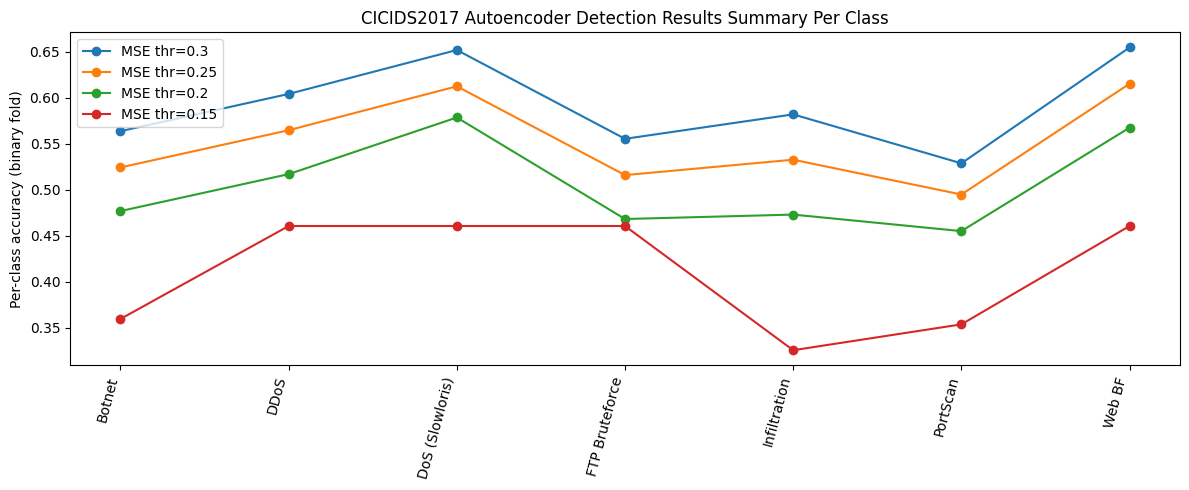

In [5]:
import matplotlib.pyplot as plt

_figd = ART_DIR / "figures"
_figd.mkdir(parents=True, exist_ok=True)

_tbl_acc = {}
_tbl_f1 = {}
for _thr in AE_TABLE_THRESHOLDS:
    _, rws = eval_thr(float(_thr))
    _tbl_acc[_thr] = {r["family"]: round(100.0 * r["accuracy"], 2) for r in rws}
    _tbl_f1[_thr] = {r["family"]: round(100.0 * r["f1_macro"], 2) for r in rws}

_sb = ae_mse_np(x_val_np)
_tbl_acc["Benign (Validation)"] = {}
_tbl_f1["Benign (Validation)"] = {}
for _thr in AE_TABLE_THRESHOLDS:
    _tbl_acc["Benign (Validation)"][_thr] = round(100.0 * float(np.mean((_sb <= _thr).astype(np.float64))), 2)
    _n = len(_sb)
    _rec = 1.0 if _n == 0 else float(np.sum((_sb > _thr).astype(np.int8) == 0)) / _n
    _tbl_f1["Benign (Validation)"][_thr] = round(100.0 * _rec, 2)

# Correctly collect only string family names from _tbl_acc
_family_names_set = set()
for key, inner_dict in _tbl_acc.items():
    if isinstance(key, float): # Only process entries where the key is a threshold (float)
        _family_names_set.update(inner_dict.keys()) # These inner_dict keys are the family names (strings)

_classes = ["Benign (Validation)"] + sorted(list(_family_names_set))

_df_ae_acc = pd.DataFrame(index=_classes, columns=[str(t) for t in AE_TABLE_THRESHOLDS])
_df_ae_f1 = pd.DataFrame(index=_classes, columns=[str(t) for t in AE_TABLE_THRESHOLDS])
for t in AE_TABLE_THRESHOLDS:
    for c in _classes:
        _df_ae_acc.loc[c, str(t)] = _tbl_acc.get(t, {}).get(c, np.nan)
        if c == "Benign (Validation)":
            _df_ae_f1.loc[c, str(t)] = _tbl_f1["Benign (Validation)"].get(t, np.nan)
        else:
            _df_ae_f1.loc[c, str(t)] = _tbl_f1.get(t, {}).get(c, np.nan)

_df_ae_acc.to_csv(_figd / "table3_ae_accuracy_cicids.csv")
_df_ae_f1.to_csv(_figd / "table3_ae_f1macro_cicids.csv")
display(_df_ae_f1)

_mat_acc = []
for _thr in AE_LINE_THRESHOLDS:
    _, rws = eval_thr(float(_thr))
    _mat_acc.append([r["accuracy"] for r in rws])
_cls_order = [r["family"] for r in rws]
plt.figure(figsize=(12, 5))
for i, thr in enumerate(AE_LINE_THRESHOLDS):
    plt.plot(range(len(_cls_order)), _mat_acc[i], marker="o", label=f"MSE thr={thr}")
plt.xticks(range(len(_cls_order)), _cls_order, rotation=75, ha="right")
plt.ylabel("Per-class accuracy (binary fold)")
plt.title("CICIDS2017 Autoencoder Detection Results Summary Per Class")
plt.legend()
plt.tight_layout()
plt.savefig(_figd / "ae_per_class_accuracy_lines.png", dpi=150)
plt.show()